In [1]:
import os
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt 

# ignite
from ignite.engine import Engine, create_supervised_trainer, create_supervised_evaluator, Events
from ignite.handlers import ModelCheckpoint, global_step_from_engine
from ignite.handlers import EarlyStopping

In [2]:
data = "/home/jovyan/DADOS-DIVIDIDOS"
feature_extract= True

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # Mais variação no corte
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(45),  # Aumentar a rotação
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.3),
        transforms.RandomAffine(degrees=0, shear=20),  # Adiciona distorção de perspectiva
        transforms.RandomPerspective(distortion_scale=0.2, p=0.5),  # Perspectiva aleatória
        transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),  # Suavização com blur
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),  # Aumenta para evitar perda de informação
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

In [3]:
dropout_rate1 = 0.332301792028777
dropout_rate2 = 0.2705522735661898
batch_size = 128
num_neurons_in = 512
num_neurons_out = 1024
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()

In [4]:
image_datasets = {x: datasets.ImageFolder(os.path.join(data, x), data_transforms[x]) for x in ['train', 'val','test']}
dataloaders_dict = {
    'train': torch.utils.data.DataLoader(image_datasets['train'], batch_size=batch_size, shuffle=True),
    'val': torch.utils.data.DataLoader(image_datasets['val'], batch_size=batch_size, shuffle=True),
    'test': torch.utils.data.DataLoader(image_datasets['test'], batch_size=batch_size, shuffle=False)
}

### Verificação da distribuição dos dados

In [10]:
labels = image_datasets['train'].targets
_,labels_count = np.unique(labels, return_counts=True)
labels_count

array([630, 754])

In [11]:
labels = image_datasets['test'].targets
_,labels_count = np.unique(labels, return_counts=True)
labels_count

array([ 92, 102])

In [12]:
labels = image_datasets['val'].targets
_,labels_count = np.unique(labels, return_counts=True)
labels_count

array([123, 150])

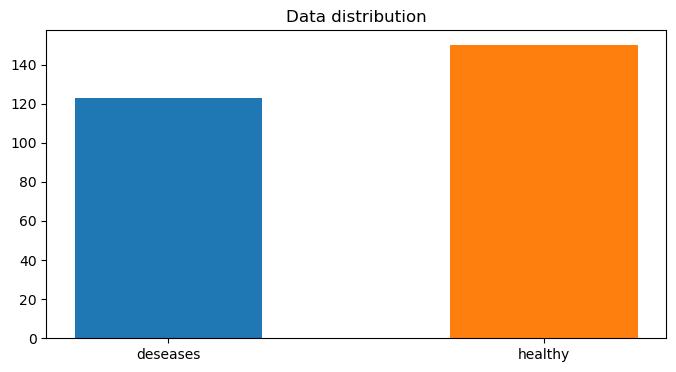

In [13]:
# Originalmente temos uma desbalanceamento dos dados -> averiguar posteriormente
class_names = image_datasets['train'].classes

plt.figure(figsize=(8, 4))
plt.title('Data distribution')
plt.bar(class_names, labels_count, width=.5, color = ['C0', 'C1'])
plt.show()

In [5]:
# Extração de features + Congelamento dos parâmetros
def set_parameter_requires_grad(model, feature_extracting):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.vgg19(pretrained=False)
set_parameter_requires_grad(model, feature_extract)

model_vgg19 = "/home/jovyan/models/VggNet19-model-96.pth"
state_dict = torch.load(model_vgg19)

del state_dict['classifier.6.weight']
del state_dict['classifier.6.bias']

model.load_state_dict(state_dict, strict=False)
model.classifier = nn.Sequential(
    nn.Linear(in_features=25088, out_features=num_neurons_out, bias=True),
    nn.ReLU(inplace=True),
    nn.Dropout(p=dropout_rate1, inplace=False),
    nn.Linear(in_features=num_neurons_out, out_features=num_neurons_in, bias=True),
    nn.ReLU(inplace=True),
    nn.Dropout(p=dropout_rate2, inplace=False),
    nn.Linear(in_features=num_neurons_in, out_features=2, bias=True),  # Saída final para 2 classes
    nn.Softmax(dim=1)
)

model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [16]:
# Parâmetros que devem ser de fato modificados
params_to_update = model.parameters()
if feature_extract:
    params_to_update = []
    for name, param in model.named_parameters():
        if param.requires_grad == True:
            params_to_update.append(param)
            print(name)
else:
    for name, param in model.named_parameters():
        if param.requires_grad:
            print(name)

classifier.0.weight
classifier.0.bias
classifier.3.weight
classifier.3.bias
classifier.6.weight
classifier.6.bias


In [6]:
train_loader = dataloaders_dict['train']
val_loader = dataloaders_dict['val']
test_loader = dataloaders_dict['test']

In [13]:
from torch.optim.lr_scheduler import StepLR
from ignite.contrib.handlers.param_scheduler import LRScheduler

# optimizer = optim.SGD(params_to_update, lr=0.001, momentum=0.9)
optimizer = optim.Adam(params_to_update, lr=0.001)
torch_lr_scheduler = StepLR(optimizer, step_size=10, gamma=0.1)
scheduler = LRScheduler(torch_lr_scheduler)
criterion = nn.CrossEntropyLoss()

/tmp/ipykernel_607501/3939743697.py:2: DeprecationWarning: /opt/conda/lib/python3.10/site-packages/ignite/contrib/handlers/param_scheduler.py has been moved to /ignite/handlers/param_scheduler.py and will be removed in version 0.6.0.
 Please refer to the documentation for more details.
  from ignite.contrib.handlers.param_scheduler import LRScheduler


In [14]:
def train_step(engine, batch):
    x, y = batch
    x = x.to(device)
    y = y.to(device)

    model.train()
    y_pred = model(x)
    loss = criterion(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss

def validation_step(engine, batch):
    model.eval()
    with torch.no_grad():
        x, y = batch[0], batch[1]
        x = x.to("cuda")
        y = y.to("cuda")

        y_pred = model(x)

        return y_pred, y
    
trainer = Engine(train_step)
evaluator = Engine(validation_step)

In [15]:
# Criação dos Events do processo de treinamento

@trainer.on(Events.STARTED)
def start_message():
    print("Start training!")

# Run train_evaluator on train_loader every trainer's epoch completed
@trainer.on(Events.EPOCH_COMPLETED)
def run_train_validation():
    train_evaluator.run(train_loader)
    
# Run evaluator on val_loader every trainer's epoch completed
@trainer.on(Events.EPOCH_COMPLETED)
def run_validation():
    evaluator.run(val_loader)

@trainer.on(Events.EPOCH_COMPLETED)
def print_lr():
    print(f"Learning rate atual: {optimizer.param_groups[0]['lr']}")
    with open("result_vgg19_final.txt", 'a', encoding='utf-8') as file:
            file.write(f"Learning rate atual: {optimizer.param_groups[0]['lr']} \n")

In [16]:
from ignite.metrics import Accuracy, Loss

# Accuracy and loss metrics are defined
val_metrics = {
  "accuracy": Accuracy(),
  "loss": Loss(criterion)
}

# Attach metrics to the evaluator
for name, metric in val_metrics.items():
    metric.attach(evaluator, name)

train_evaluator = create_supervised_evaluator(model, metrics=val_metrics, device=device)

In [17]:
train_losses = []
val_losses = []
train_accs = []
val_accs = []

@train_evaluator.on(Events.COMPLETED)
def log_train_results():
    metrics = train_evaluator.state.metrics
    train_acc = metrics['accuracy']
    train_loss = metrics['loss']
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    print("  Training Results - Epoch: {}  Avg accuracy: {:.3f} Avg loss: {:.3f}"
          .format(trainer.state.epoch, metrics["accuracy"], metrics["loss"]))
    with open("result_vgg19_final.txt", 'a', encoding='utf-8') as file:
        file.write("  Training Results - Epoch: {}  Avg accuracy: {:.3f} Avg loss: {:.3f} \n"
          .format(trainer.state.epoch, metrics["accuracy"], metrics["loss"]))
    
@evaluator.on(Events.COMPLETED)
def log_validation_results():
    metrics = evaluator.state.metrics
    val_acc = metrics['accuracy']
    val_loss = metrics['loss']
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    print("Validation Results - Epoch: {}  Avg accuracy: {:.3f} Avg loss: {:.3f} "
          .format(trainer.state.epoch, metrics["accuracy"], metrics["loss"]))
    with open("result_vgg19_final.txt", 'a', encoding='utf-8') as file:
        file.write("Validation Results - Epoch: {}  Avg accuracy: {:.3f} Avg loss: {:.3f} \n"
          .format(trainer.state.epoch, metrics["accuracy"], metrics["loss"]))


In [18]:
def score_function(engine):
    return engine.state.metrics["accuracy"]

early_stopping = EarlyStopping(patience=50, score_function=score_function, trainer=trainer)
evaluator.add_event_handler(Events.COMPLETED, early_stopping)

model_checkpoint = ModelCheckpoint(
    "final-result",
    n_saved=5,
    filename_prefix="best",
    score_function=score_function,
    score_name="accuracy",
    global_step_transform=global_step_from_engine(trainer),
)
  

evaluator.add_event_handler(Events.COMPLETED, model_checkpoint, {"model": model});

trainer.add_event_handler(Events.EPOCH_STARTED, scheduler)

In [19]:
trainer.run(train_loader, max_epochs=500)

Start training!
  Training Results - Epoch: 1  Avg accuracy: 0.864 Avg loss: 0.439
Validation Results - Epoch: 1  Avg accuracy: 0.930 Avg loss: 0.379 
Learning rate atual: 0.001
  Training Results - Epoch: 2  Avg accuracy: 0.887 Avg loss: 0.424
Validation Results - Epoch: 2  Avg accuracy: 0.941 Avg loss: 0.369 
Learning rate atual: 0.001
  Training Results - Epoch: 3  Avg accuracy: 0.837 Avg loss: 0.470
Validation Results - Epoch: 3  Avg accuracy: 0.960 Avg loss: 0.351 
Learning rate atual: 0.001
  Training Results - Epoch: 4  Avg accuracy: 0.878 Avg loss: 0.433
Validation Results - Epoch: 4  Avg accuracy: 0.949 Avg loss: 0.362 
Learning rate atual: 0.001
  Training Results - Epoch: 5  Avg accuracy: 0.864 Avg loss: 0.441
Validation Results - Epoch: 5  Avg accuracy: 0.952 Avg loss: 0.361 
Learning rate atual: 0.001
  Training Results - Epoch: 6  Avg accuracy: 0.900 Avg loss: 0.410
Validation Results - Epoch: 6  Avg accuracy: 0.945 Avg loss: 0.366 
Learning rate atual: 0.001
  Training R

2025-02-18 22:39:25,657 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


Validation Results - Epoch: 62  Avg accuracy: 0.960 Avg loss: 0.354 
Learning rate atual: 1.0000000000000005e-09


State:
	iteration: 682
	epoch: 62
	epoch_length: 11
	max_epochs: 500
	output: <class 'torch.Tensor'>
	batch: <class 'list'>
	metrics: <class 'dict'>
	dataloader: <class 'torch.utils.data.dataloader.DataLoader'>
	seed: <class 'NoneType'>
	times: <class 'dict'>

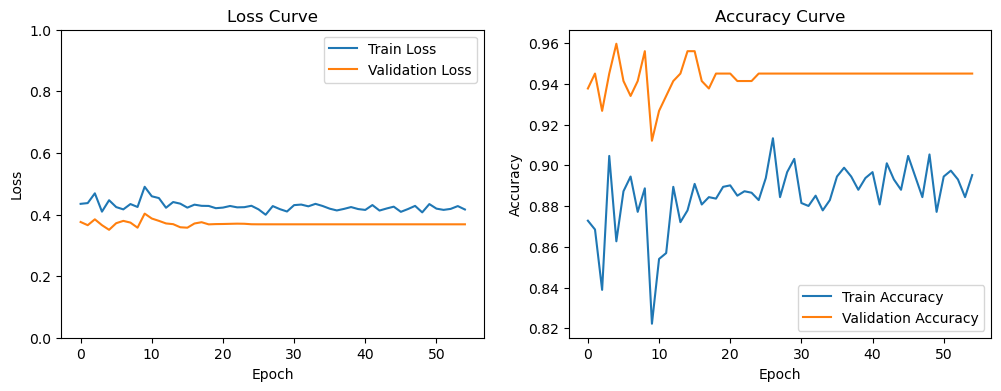

In [17]:
# Plotagem da curva de aprendizagem
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')
plt.ylim([0, 1])


plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curve')

plt.show()

## Inferência do Modelo

In [7]:
model_inference = models.vgg19(pretrained=False)

# Carregar o estado salvo do modelo
model_weights_inference = "/home/jovyan/VGG19/final-result/best_model_17_accuracy=0.9634.pt"
state_dict = torch.load(model_weights_inference)

# Remover os pesos e bias da última camada
del state_dict['classifier.6.weight']
del state_dict['classifier.6.bias']

# Carregar o state_dict no modelo, ignorando a última camada
model_inference.load_state_dict(state_dict, strict=False)

# Modificar a camada de classificação para 2 classes
model_inference.classifier = nn.Sequential(
    nn.Linear(in_features=25088, out_features=num_neurons_out, bias=True),
    nn.ReLU(inplace=True),
    nn.Dropout(p=dropout_rate1, inplace=False),
    nn.Linear(in_features=num_neurons_out, out_features=num_neurons_in, bias=True),
    nn.ReLU(inplace=True),
    nn.Dropout(p=dropout_rate2, inplace=False),
    nn.Linear(in_features=num_neurons_in, out_features=2, bias=True),  # Saída final para 2 classes
    nn.Softmax(dim=1)
)


# Enviar para o dispositivo (CPU ou GPU)
device = "cpu"
model_inference.to(device)


/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


RuntimeError: Error(s) in loading state_dict for VGG:
	size mismatch for classifier.0.weight: copying a param with shape torch.Size([1024, 25088]) from checkpoint, the shape in current model is torch.Size([4096, 25088]).
	size mismatch for classifier.0.bias: copying a param with shape torch.Size([1024]) from checkpoint, the shape in current model is torch.Size([4096]).
	size mismatch for classifier.3.weight: copying a param with shape torch.Size([512, 1024]) from checkpoint, the shape in current model is torch.Size([4096, 4096]).
	size mismatch for classifier.3.bias: copying a param with shape torch.Size([512]) from checkpoint, the shape in current model is torch.Size([4096]).

In [8]:
model_inference = models.vgg19(pretrained=False)
num_features = model_inference.classifier[0].in_features

model_inference.classifier = nn.Sequential(
    nn.Linear(in_features=25088, out_features=num_neurons_out, bias=True),
    nn.ReLU(inplace=True),
    nn.Dropout(p=dropout_rate1, inplace=False),
    nn.Linear(in_features=num_neurons_out, out_features=num_neurons_in, bias=True),
    nn.ReLU(inplace=True),
    nn.Dropout(p=dropout_rate2, inplace=False),
    nn.Linear(in_features=num_neurons_in, out_features=2, bias=True),  # Saída final para 2 classes
    nn.Softmax(dim=1)
)

model_path = "/home/jovyan/VGG19/final-result/best_model_17_accuracy=0.9634.pt"
model_inference.load_state_dict(torch.load(model_path))

device = "cpu"
model_inference.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [9]:
def test_step(engine, batch):
    model_inference.eval()
    with torch.no_grad():
        x, y = batch
        x = x.to(device)
        y = y.to(device)

        y_pred = model_inference(x)
        return y_pred, y
    
test_evaluator = Engine(test_step)

In [10]:
from ignite.metrics import Accuracy, Loss

criterion = nn.CrossEntropyLoss()

test_metrics = {
    "accuracy": Accuracy(),
    "loss": Loss(criterion)
}

In [11]:
for name, metric in test_metrics.items():
    metric.attach(test_evaluator, name)

In [12]:
@test_evaluator.on(Events.COMPLETED)
def log_test_results(engine):
    metrics = engine.state.metrics
    test_acc = metrics['accuracy']
    test_loss = metrics['loss']
    print("Test Results - Avg accuracy: {:.3f} Avg loss: {:.3f}"
          .format(test_acc, test_loss))

# Rodando o evaluator de teste no test_loader
test_evaluator.run(test_loader)

Test Results - Avg accuracy: 0.964 Avg loss: 0.351


State:
	iteration: 2
	epoch: 1
	epoch_length: 2
	max_epochs: 1
	output: <class 'tuple'>
	batch: <class 'list'>
	metrics: <class 'dict'>
	dataloader: <class 'torch.utils.data.dataloader.DataLoader'>
	seed: <class 'NoneType'>
	times: <class 'dict'>

In [13]:
# Função para realizar a inferência
def inference(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_preds, all_labels

In [14]:
predictions, true_labels = inference(model_inference, test_loader, device)

In [15]:
correct = sum(p == t for p, t in zip(predictions, true_labels))
total = len(true_labels)
accuracy = correct / total
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.9639


In [16]:
from sklearn.metrics import f1_score
macro_f1 = f1_score(true_labels, predictions, average='macro')
print(f'Macro F1-Score: {macro_f1:.4f}')

Macro F1-Score: 0.9637


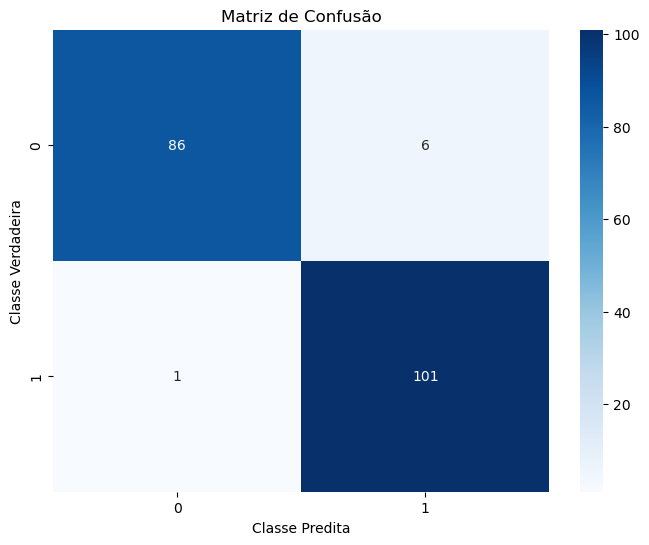

In [17]:
# Matriz de Confusão
from sklearn.metrics import confusion_matrix
import seaborn as sns

conf_matrix = confusion_matrix(true_labels, predictions)

# Exibir a matriz de confusão usando seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Classe Predita')
plt.ylabel('Classe Verdadeira')
plt.title('Matriz de Confusão')
plt.show()